# EDA — Exploratory Data Analysis · single-cell RNA-seq (PBMC)

**Obiettivo (Project 2).** Capire *come è fatto* il dataset prima di addestrare i classificatori.
Tutto ciò che osserviamo qui serve da riferimento per interpretare le performance dei modelli
e giustificare le scelte metodologiche.

## Struttura del notebook
| Sezione | Contenuto |
|---|---|
| 1 | Struttura del dataset (shape, dtype, nulli, range) |
| 2 | Distribuzione delle classi — sbilanciamento |
| 3 | Analisi dei geni discriminanti (criterio 1σ) |
| 4 | Heatmap z-score delle medie per classe |
| 5 | Gruppi di geni funzionali (biologia + varianza) |
| 6 | Boxplot dei top geni per gruppo biologico |
| 7 | Co-espressione — matrice di correlazione |
| 8 | PCA: varianza spiegata + scatter 2D |
| 9 | Conclusioni — collegamento con i modelli |

> **Nota.** I dati sono già normalizzati dal corso (QC, HVG, batch correction).
> Lo split train/test è predefinito e **non va rimescolato**. Qui solo osserviamo.

In [1]:
# ── Bootstrap: trova la radice del progetto ──────────────────────────────────
import sys, pathlib

def _find_root(start=None):
    p = (start or pathlib.Path.cwd()).resolve()
    for _ in range(6):
        if (p / "src" / "setup.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Radice del progetto non trovata (manca src/setup.py).\n"
        "Apri il notebook dalla cartella del repo o da notebooks/."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification


In [2]:
# ── Import ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.data_loader import load_datasets
from src.setup import FIGURES_DIR
from src.gene_groups import GENE_SUBGROUPS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train, X_test, y_train, y_test = load_datasets()
print(f"Train: {X_train.shape[0]} celle × {X_train.shape[1]} geni")
print(f"Test : {X_test.shape[0]} celle × {X_test.shape[1]} geni")

Train: 4516 celle × 1976 geni
Test : 1129 celle × 1976 geni


---
## 1 · Struttura del dataset

Ogni **riga** è una cellula, ogni **colonna** un gene (Highly Variable Gene selezionato dal corso).
Verifichiamo dimensioni, tipi di dato, valori nulli e coerenza tra train e test.

In [3]:
def struttura(X, nome):
    print(f"── {nome} ──────────────────────")
    print(f"  Shape   : {X.shape[0]} celle × {X.shape[1]} geni")
    print(f"  Dtype   : {dict(X.dtypes.value_counts())}")
    print(f"  Memoria : {X.memory_usage().sum() / 1e6:.1f} MB")
    print(f"  Nulli   : {int(X.isna().sum().sum())}")
    print()

struttura(X_train, "X_train")
struttura(X_test,  "X_test")

print("Stessi geni in train e test?", list(X_train.columns) == list(X_test.columns))

# Controllo leakage
n_dup_tr = int(X_train.duplicated().sum())
n_dup_te = int(X_test.duplicated().sum())
combined = pd.concat([X_train, X_test], ignore_index=True)
overlap  = max(int(combined.duplicated().sum()) - n_dup_tr - n_dup_te, 0)
print(f"\nDuplicati interni — train: {n_dup_tr} | test: {n_dup_te}")
print(f"Celle condivise train/test (potenziale leakage): {overlap}")
print("OK — nessun leakage." if overlap == 0 else "⚠ Attenzione: possibile leakage!")

── X_train ──────────────────────
  Shape   : 4516 celle × 1976 geni
  Dtype   : {dtype('float64'): np.int64(1976)}
  Memoria : 71.4 MB
  Nulli   : 0

── X_test ──────────────────────
  Shape   : 1129 celle × 1976 geni
  Dtype   : {dtype('float64'): np.int64(1976)}
  Memoria : 17.8 MB


  Nulli   : 0

Stessi geni in train e test? True



Duplicati interni — train: 0 | test: 0
Celle condivise train/test (potenziale leakage): 0
OK — nessun leakage.


In [4]:
# Statistiche descrittive su un campione di geni
print("Statistiche descrittive (primi 6 geni, train):")
X_train.iloc[:, :6].describe().round(3)

Statistiche descrittive (primi 6 geni, train):


,HES4,ISG15,TNFRSF18,TNFRSF4,B3GALT6,ACAP3
count,4516.000,4516.000,4516.000,4516.000,4516.000,4516.000
mean,-0.010,0.004,0.007,0.001,0.001,0.010
std,0.983,1.007,1.019,0.995,1.000,1.019
min,-0.295,-0.749,-0.240,-0.205,-0.301,-0.327
25%,-0.295,-0.749,-0.240,-0.205,-0.301,-0.327
50%,-0.295,-0.749,-0.240,-0.205,-0.301,-0.327
75%,-0.295,0.476,-0.240,-0.205,-0.301,-0.327
max,8.590,4.482,9.301,11.516,9.830,10.565


**Lettura.** I valori sono centrati intorno a 0 con deviazione standard ~1: la normalizzazione
(log-normalizzazione + z-score) è già stata applicata. Nessun valore nullo → il dataset è pulito.

---
## 2 · Distribuzione delle classi — sbilanciamento

Il dataset è **fortemente sbilanciato**: alcune classi hanno migliaia di celle, altre solo 2–3.
Questo ha conseguenze dirette sulle metriche: l'**accuracy** da sola è ingannevole;
useremo **Macro F1** e **balanced accuracy** nei modelli.

Visualizziamo train e test affiancati per verificare che lo sbilanciamento sia coerente.

In [5]:
counts = pd.DataFrame({
    "train": y_train.value_counts(),
    "test" : y_test.value_counts(),
}).fillna(0).astype(int).sort_values("train", ascending=False)

# Rapporto classe più frequente / più rara
ratio_imb = counts["train"].max() / counts["train"].min()
print(f"Classe più frequente (train): '{counts['train'].idxmax()}' → {counts['train'].max()} celle")
print(f"Classe più rara    (train): '{counts['train'].idxmin()}' → {counts['train'].min()} celle")
print(f"Rapporto di sbilanciamento: {ratio_imb:.0f}:1\n")
print(counts.to_string())

Classe più frequente (train): 'CD14 Monocyte' → 1511 celle
Classe più rara    (train): 'Neutrophil' → 2 celle
Rapporto di sbilanciamento: 756:1

                  train  test
cell_type                    
CD14 Monocyte      1511   378
CD8m T              814   204
NK                  710   178
B                   646   162
CD4n T              219    54
Platelet            137    34
CD16 Monocyte       133    33
gd T                127    32
CD4m T              108    27
DC                   31     8
CD8eff T             22     6
CD4 T                20     5
IgA PB               15     3
pDC                   7     2
RBC                   4     1
IgG PB                4     1
Class-switched B      3     1
SC & Eosinophil       3     0
Neutrophil            2     0


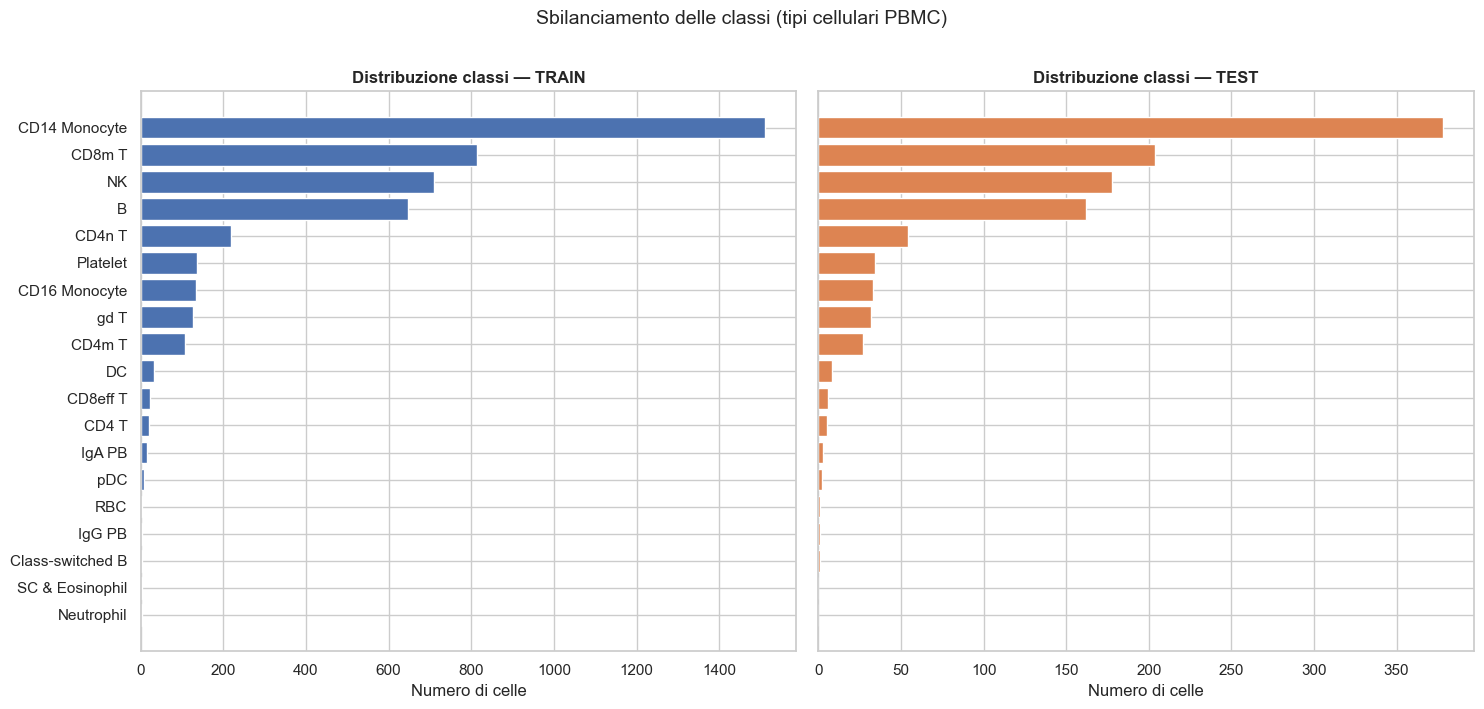

Figura salvata.


In [6]:
order = counts.index[::-1]
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

axes[0].barh(order, counts.loc[order, "train"], color="#4c72b0")
axes[0].set_title("Distribuzione classi — TRAIN", fontweight="bold")
axes[0].set_xlabel("Numero di celle")

axes[1].barh(order, counts.loc[order, "test"], color="#dd8452")
axes[1].set_title("Distribuzione classi — TEST", fontweight="bold")
axes[1].set_xlabel("Numero di celle")

plt.suptitle("Sbilanciamento delle classi (tipi cellulari PBMC)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

**Conseguenza metodologica.** Il rapporto di sbilanciamento è estremo.
Nei modelli useremo `class_weight='balanced'` per non penalizzare le classi rare,
e valuteremo con **Macro F1** e **balanced accuracy** invece della sola accuracy.

---
## 3 · Analisi dei geni discriminanti — criterio 1σ

Un gene è **discriminante** se la sua espressione varia molto *tra classi*.
Criterio: l'**escursione tra classi** (max media − min media) supera **1 deviazione standard globale**
del gene. È un criterio statistico, indipendente dal modello, che identifica i geni marcatori
**prima ancora di addestrare** il classificatore.

Geni come **IL7R, PF4, CD3E** emergono
dall'analisi statistica come marcatori delle classi attese (T-cell, Platelet), senza essere scelti a priori.

In [7]:
# Media per classe (righe = tipo cellulare, colonne = geni)
df_tr = X_train.copy()
df_tr["cell_type"] = y_train.values
class_means = df_tr.groupby("cell_type").mean()
global_std  = X_train.std()

# Escursione tra classi per ogni gene
spread = class_means.max(axis=0) - class_means.min(axis=0)
ratio  = (spread / global_std).sort_values(ascending=False)

n_signif = int((spread > global_std).sum())
print(f"Geni con escursione > 1σ (discriminanti): {n_signif} su {X_train.shape[1]}")
print(f"({n_signif/X_train.shape[1]*100:.1f}% dei geni totali)\n")

# Tabella top 20
top20 = ratio.head(20)
tabella = pd.DataFrame({
    "classe_max"    : class_means[top20.index].idxmax(),
    "media_max"     : class_means[top20.index].max().round(3),
    "classe_min"    : class_means[top20.index].idxmin(),
    "media_min"     : class_means[top20.index].min().round(3),
    "escursione"    : spread[top20.index].round(3),
    "sigma_globale" : global_std[top20.index].round(3),
    "rapporto_sigma": top20.round(3),
})
print("Top 20 geni più discriminanti:")
tabella

Geni con escursione > 1σ (discriminanti): 1199 su 1976
(60.7% dei geni totali)

Top 20 geni più discriminanti:


,classe_max,media_max,classe_min,media_min,escursione,sigma_globale,rapporto_sigma
IGHG1,IgG PB,13.272,Class-switched B,-0.186,13.458,0.986,13.651
IGHG4,IgG PB,11.727,CD4 T,-0.194,11.922,0.998,11.951
SERPINF1,pDC,11.666,CD4 T,-0.104,11.770,0.987,11.922
IGHG3,IgG PB,9.902,Class-switched B,-0.228,10.130,0.996,10.173
LINC02018,Class-switched B,9.061,CD4 T,-0.067,9.128,0.954,9.569
HEMGN,Class-switched B,9.022,B,-0.063,9.086,0.985,9.224
MYBL2,IgG PB,8.884,CD16 Monocyte,-0.109,8.993,0.976,9.215
GPR107,Neutrophil,8.754,CD4 T,-0.264,9.018,1.008,8.947
ZNF41,Class-switched B,8.513,CD4 T,-0.113,8.626,0.964,8.945
IGKV4-1,IgG PB,9.253,NK,-0.058,9.311,1.048,8.882


In [8]:
# Verifica esplicita di alcuni geni marcatori noti
geni_marcatori = ["IL7R", "PF4", "CD3E"]
print("── Geni marcatori noti ──────────────────────────")
for gene in geni_marcatori:
    if gene not in ratio.index:
        print(f"  {gene}: NON presente negli HVG del dataset")
        continue
    rank = int((ratio > ratio[gene]).sum()) + 1
    cls_max = class_means[gene].idxmax()
    cls_min = class_means[gene].idxmin()
    val_max = class_means[gene].max()
    val_min = class_means[gene].min()
    print(f"  {gene:>5s}: rank #{rank:>3d} | "
          f"più espresso in '{cls_max}' (media={val_max:.3f}) | "
          f"meno in '{cls_min}' (media={val_min:.3f}) | "
          f"rapporto={ratio[gene]:.2f}σ")

── Geni marcatori noti ──────────────────────────
   IL7R: rank #394 | più espresso in 'CD4m T' (media=1.863) | meno in 'Class-switched B' (media=-0.536) | rapporto=2.39σ
    PF4: rank #121 | più espresso in 'Platelet' (media=3.788) | meno in 'SC & Eosinophil' (media=-0.389) | rapporto=4.18σ
   CD3E: rank #575 | più espresso in 'CD8m T' (media=1.176) | meno in 'Class-switched B' (media=-0.756) | rapporto=1.93σ


**Interpretazione.** IL7R e CD3E sono marcatori dei linfociti T (CD4+ e CD8+);
PF4 è specifico delle piastrine. Il criterio 1σ li identifica statisticamente
senza alcun input dal modello — questo sarà confermato da feature importance e SHAP
nel notebook `Machine_learning_models.ipynb`.

---
## 4 · Heatmap z-score delle medie per classe

Visualizziamo i top geni discriminanti (sez. 3): **verde** = gene più espresso in quella
classe, **rosso** = meno espresso. Un blocco di verde isolato = gene marcatore specifico.

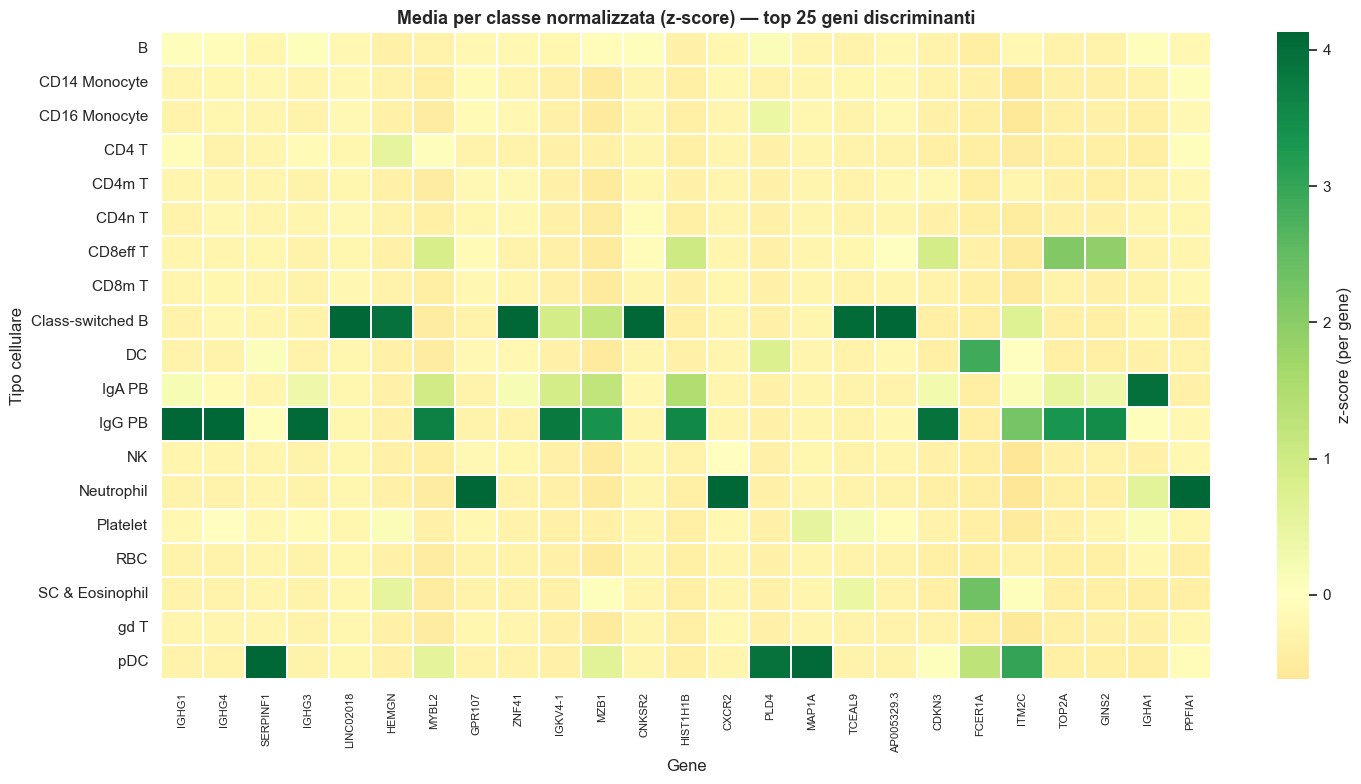

Figura salvata.


In [9]:
top_genes_hm = ratio.head(25).index
means_sub    = class_means[top_genes_hm]
means_norm   = (means_sub - means_sub.mean()) / (means_sub.std() + 1e-9)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    means_norm, annot=False, cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.3, cbar_kws={"label": "z-score (per gene)"}
)
ax.set_title("Media per classe normalizzata (z-score) — top 25 geni discriminanti",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Gene"); ax.set_ylabel("Tipo cellulare")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_heatmap_zscore.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

**Lettura.** Righe = tipi cellulari, colonne = geni. Un verde acceso isolato indica un gene
sovraespresso quasi solo in quella classe → marcatore forte per il classificatore.

---
## 5 · Gruppi di geni funzionali

Analizziamo i geni da **due angolazioni complementari**:

- **5a — Gruppi biologici**: i geni conosciuti come marcatori di specifici tipi cellulari
  (da `gene_groups.py`), come IL7R, PF4, CD3E.
- **5b — Gruppi per varianza**: dividiamo tutti i 1976 geni in terzili
  (alta / media / bassa variabilità) e verifichiamo se la variabilità *grezza* di un gene
  predice il suo potere discriminante. Anticipiamo il risultato: i due aspetti sono in gran
  parte **indipendenti**.

In [10]:
# ── 5a · Gruppi biologici ────────────────────────────────────────────────────
print("Gruppi biologici definiti in gene_groups.py:")
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in X_train.columns]
    print(f"  {gruppo:20s}: {len(presenti):>2d}/{len(geni)} geni presenti negli HVG")
    if presenti:
        print(f"    → {', '.join(presenti)}")

Gruppi biologici definiti in gene_groups.py:
  T_cell              :  7/8 geni presenti negli HVG
    → CD3E, CD3D, CD3G, IL7R, TRAC, CD8A, CD8B
  B_cell              :  6/8 geni presenti negli HVG
    → MS4A1, CD79A, CD79B, JCHAIN, IGHA1, IGHG1
  Myeloid             :  4/7 geni presenti negli HVG
    → FCGR3A, CD14, CST3, TYROBP
  NK                  :  3/5 geni presenti negli HVG
    → PRF1, GZMB, KLRD1
  Platelet            :  2/2 geni presenti negli HVG
    → PPBP, PF4
  DC_pDC              :  3/4 geni presenti negli HVG
    → FCER1A, CST3, GZMB
  Interferon_ISG      :  4/4 geni presenti negli HVG
    → ISG15, MX1, IFIT1, IFIT3
  MHC                 :  4/4 geni presenti negli HVG
    → HLA-DRA, HLA-DRB1, HLA-DPA1, HLA-DPB1


In [11]:
# Per ogni gruppo biologico: media del rapporto sigma dei suoi geni
print("\nPotere discriminante medio per gruppo biologico (rapporto σ):")
rows_bio = []
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in ratio.index]
    if not presenti:
        continue
    media_ratio = ratio[presenti].mean()
    max_gene    = ratio[presenti].idxmax()
    rows_bio.append({
        "gruppo"          : gruppo,
        "geni_HVG"        : len(presenti),
        "ratio_sigma_medio": round(media_ratio, 3),
        "gene_più_forte"  : max_gene,
        "ratio_max"       : round(ratio[max_gene], 3),
    })
bio_df = pd.DataFrame(rows_bio).sort_values("ratio_sigma_medio", ascending=False)
bio_df


Potere discriminante medio per gruppo biologico (rapporto σ):


,gruppo,geni_HVG,ratio_sigma_medio,gene_più_forte,ratio_max
1,B_cell,6,5.764,IGHG1,13.651
5,DC_pDC,3,4.234,FCER1A,7.505
4,Platelet,2,3.948,PF4,4.182
7,MHC,4,3.230,HLA-DPB1,3.421
2,Myeloid,4,2.410,FCGR3A,2.920
3,NK,3,2.278,GZMB,2.451
0,T_cell,7,1.903,IL7R,2.386
6,Interferon_ISG,4,0.857,MX1,1.223


In [12]:
# ── 5b · Gruppi per varianza (terzili) ──────────────────────────────────────
gene_var    = X_train.var(axis=0).sort_values(ascending=False)
n_genes     = len(gene_var)
terzile     = n_genes // 3

top_var     = gene_var.head(terzile).index          # alta variabilità
mid_var     = gene_var.iloc[terzile:2*terzile].index # media variabilità
low_var     = gene_var.tail(terzile).index           # bassa variabilità

# Quanti geni discriminanti (>1σ) cadono in ogni terzile?
signif_genes = ratio[ratio > 1].index

def pct(subset, total_signif):
    n = len(set(subset) & set(total_signif))
    return n, (f"{n/len(total_signif)*100:.1f}%" if len(total_signif) else "—")

n_top, p_top = pct(top_var, signif_genes)
n_mid, p_mid = pct(mid_var, signif_genes)
n_low, p_low = pct(low_var, signif_genes)

print("Distribuzione dei geni discriminanti (>1σ) nei terzili di varianza:")
print(f"  Terzile ALTA varianza  ({len(top_var)} geni): {n_top} discriminanti → {p_top} del totale")
print(f"  Terzile MEDIA varianza ({len(mid_var)} geni): {n_mid} discriminanti → {p_mid} del totale")
print(f"  Terzile BASSA varianza ({len(low_var)} geni): {n_low} discriminanti → {p_low} del totale")

# Correlazione tra variabilità grezza e potere discriminante (rapporto σ)
corr_var_ratio = np.corrcoef(gene_var.values, ratio[gene_var.index].values)[0, 1]
print(f"\nCorrelazione (varianza grezza vs rapporto σ): {corr_var_ratio:.3f}")
print("→ Vicina a 0: la variabilità grezza NON predice il potere discriminante.")

Distribuzione dei geni discriminanti (>1σ) nei terzili di varianza:
  Terzile ALTA varianza  (658 geni): 368 discriminanti → 30.7% del totale
  Terzile MEDIA varianza (658 geni): 462 discriminanti → 38.5% del totale
  Terzile BASSA varianza (658 geni): 368 discriminanti → 30.7% del totale

Correlazione (varianza grezza vs rapporto σ): -0.076
→ Vicina a 0: la variabilità grezza NON predice il potere discriminante.


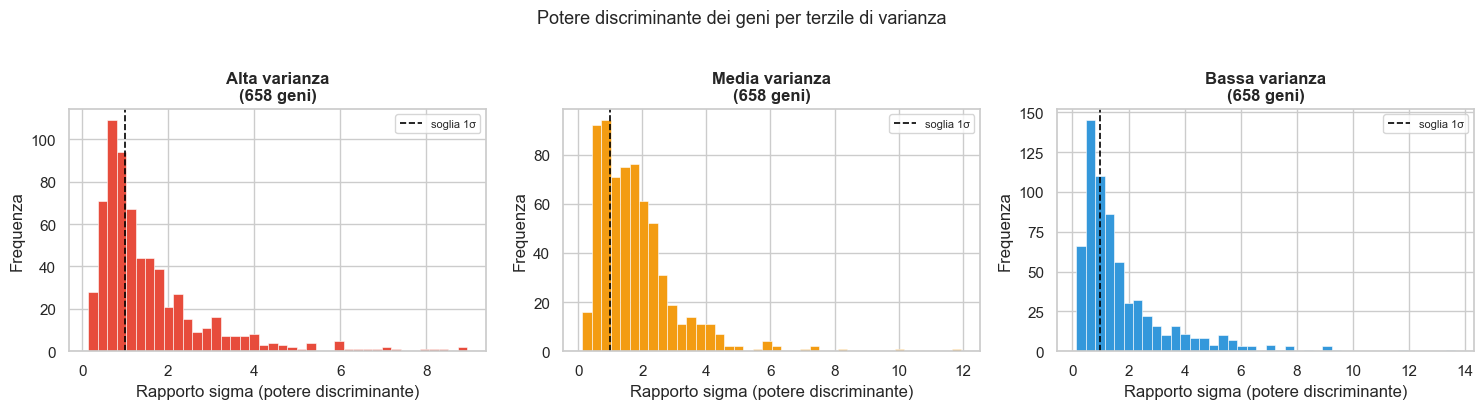

Figura salvata.


In [13]:
# Visualizzazione: distribuzione del rapporto sigma per terzile
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colori = ["#e74c3c", "#f39c12", "#3498db"]
label_terzili = ["Alta varianza", "Media varianza", "Bassa varianza"]

for ax, subset, colore, label in zip(axes, [top_var, mid_var, low_var], colori, label_terzili):
    vals = ratio[subset].values
    ax.hist(vals, bins=40, color=colore, edgecolor="white", linewidth=0.4)
    ax.axvline(1.0, ls="--", color="black", lw=1.2, label="soglia 1σ")
    ax.set_title(f"{label}\n({len(subset)} geni)", fontweight="bold")
    ax.set_xlabel("Rapporto sigma (potere discriminante)")
    ax.set_ylabel("Frequenza")
    ax.legend(fontsize=8)

plt.suptitle("Potere discriminante dei geni per terzile di varianza", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_gene_terzili_varianza.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

**Interpretazione.**
- I geni discriminanti (>1σ) si distribuiscono in **tutti** i terzili di varianza e la
  correlazione tra variabilità grezza e potere discriminante è quasi nulla.
- Un gene può quindi essere informativo pur avendo varianza complessiva modesta: basta che sia
  espresso in modo **specifico** in una classe e quasi assente nelle altre, con poco rumore.
- I gruppi biologici restano coerenti con la letteratura: T-cell (IL7R, CD3E),
  Platelet (PF4), NK (NKG7), Myeloid (LYZ, S100A8).

---
## 6 · Boxplot dei top geni per gruppo biologico

Per un gene rappresentativo di ogni gruppo biologico, mostriamo la distribuzione
(mediana, quartili, outlier) nelle **classi più frequenti**: conferma visiva dei marcatori.

In [14]:
# Selezioniamo un gene rappresentativo per ogni gruppo biologico
rep_genes = {}
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in ratio.index]
    if presenti:
        # il gene più discriminante del gruppo
        best = ratio[presenti].idxmax()
        rep_genes[gruppo] = best

print("Gene rappresentativo selezionato per ogni gruppo:")
for g, gene in rep_genes.items():
    print(f"  {g:20s} → {gene} (ratio σ = {ratio[gene]:.2f})")

Gene rappresentativo selezionato per ogni gruppo:
  T_cell               → IL7R (ratio σ = 2.39)
  B_cell               → IGHG1 (ratio σ = 13.65)
  Myeloid              → FCGR3A (ratio σ = 2.92)
  NK                   → GZMB (ratio σ = 2.45)
  Platelet             → PF4 (ratio σ = 4.18)
  DC_pDC               → FCER1A (ratio σ = 7.50)
  Interferon_ISG       → MX1 (ratio σ = 1.22)
  MHC                  → HLA-DPB1 (ratio σ = 3.42)


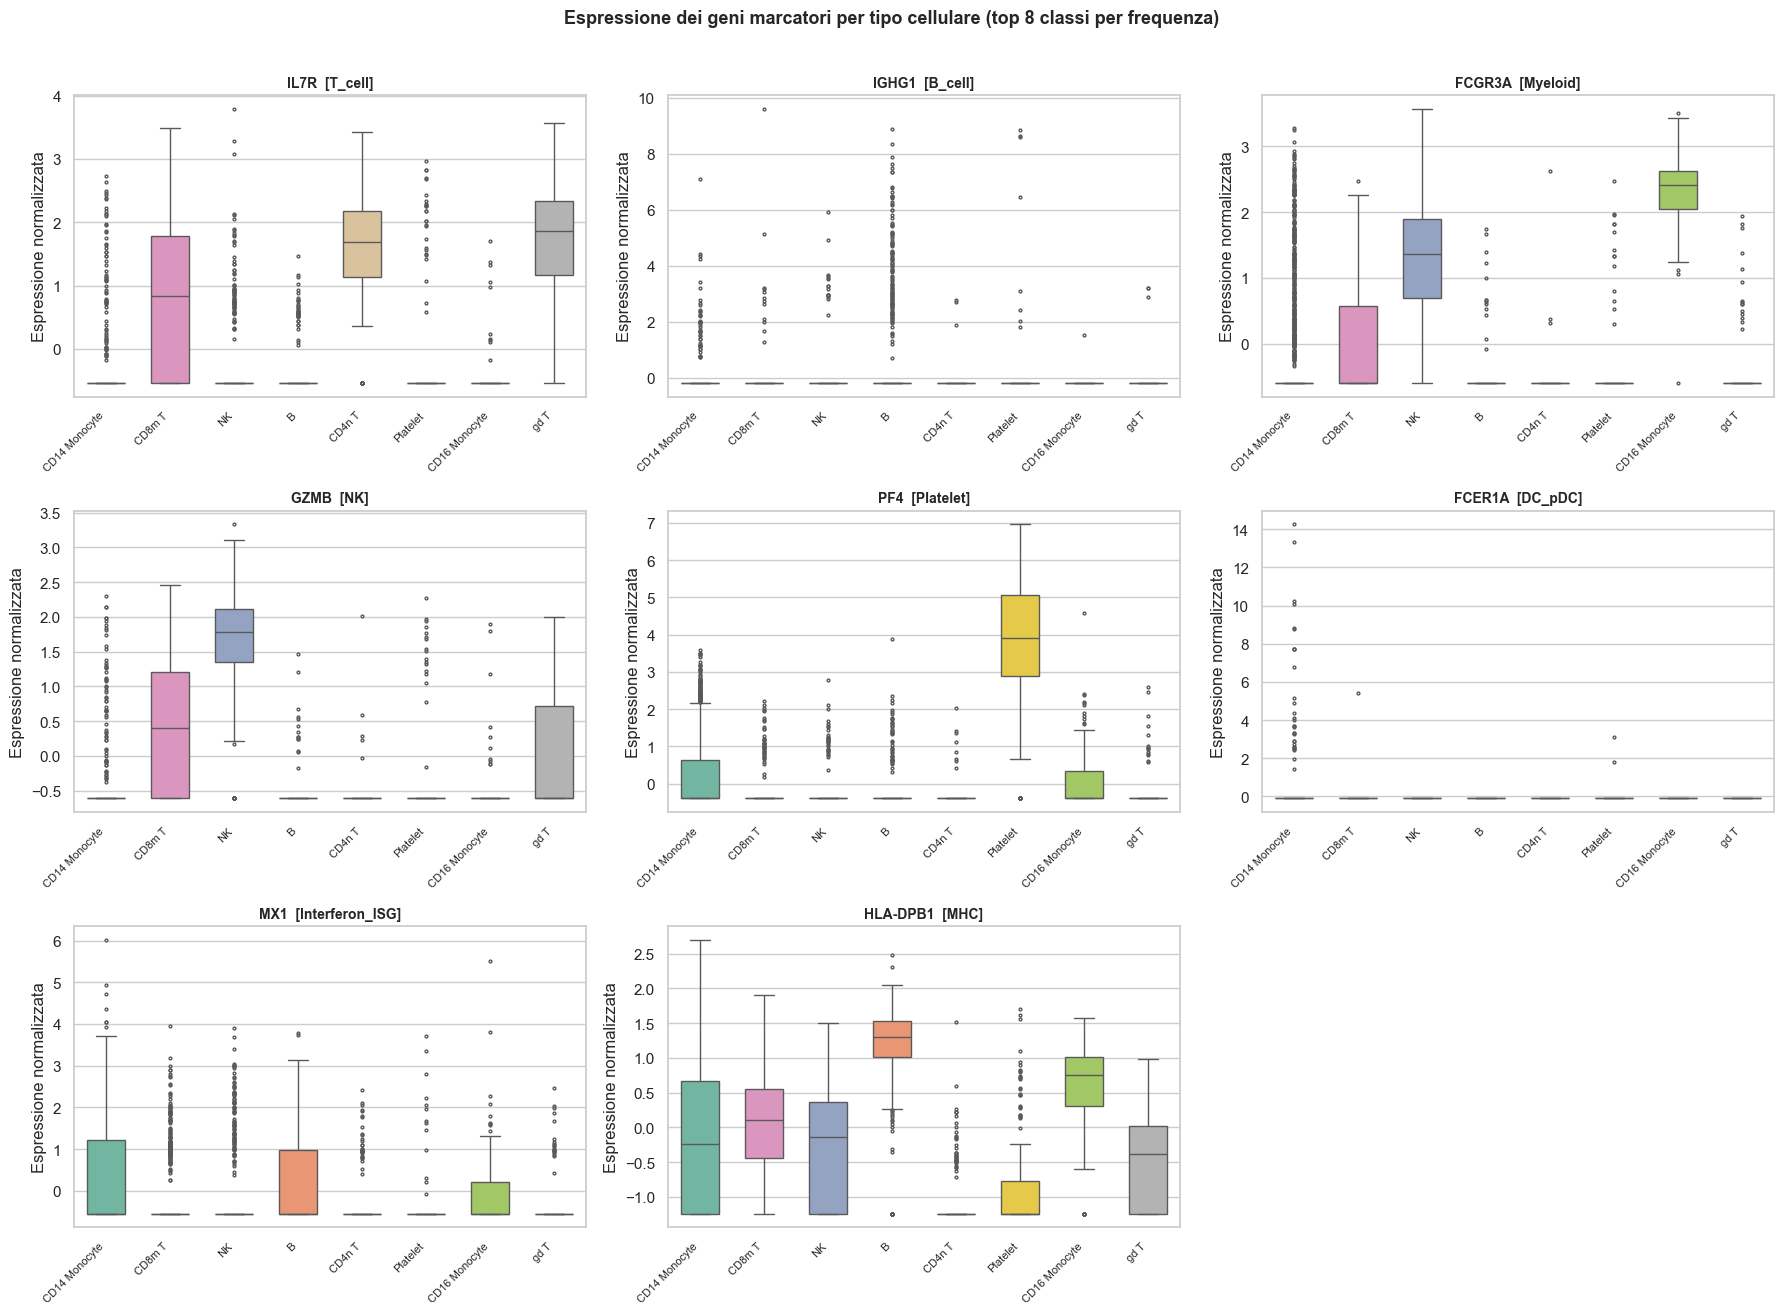

Figura salvata.


In [15]:
# Top 8 classi per frequenza (leggibilità)
top_classes = y_train.value_counts().head(8).index.tolist()
mask_tc     = y_train.isin(top_classes)
genes_plot  = list(rep_genes.values())[:9]   # max 9 subplot
n_plots     = len(genes_plot)

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes_flat = axes.flatten()

for i, gene in enumerate(genes_plot):
    ax = axes_flat[i]
    data = pd.DataFrame({
        "cell_type" : y_train[mask_tc].values,
        gene        : X_train.loc[mask_tc, gene].values
    })
    sns.boxplot(
        data=data, x="cell_type", y=gene, order=top_classes,
        hue="cell_type", legend=False,
        ax=ax, width=0.6, fliersize=2,
        palette="Set2"
    )
    # Gruppo di appartenenza
    gruppo = next((g for g, v in rep_genes.items() if v == gene), "")
    ax.set_title(f"{gene}  [{gruppo}]", fontweight="bold", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Espressione normalizzata")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Nascondi subplot vuoti
for j in range(n_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    "Espressione dei geni marcatori per tipo cellulare (top 8 classi per frequenza)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_boxplot_marker_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

**Lettura.** Un buon marcatore ha la scatola **alta** nella sua classe e **bassa** nelle altre:
più le scatole sono separate, più il gene è utile per il classificatore.

---
## 7 · Co-espressione — matrice di correlazione

Su dati scRNA-seq alcuni geni sono **co-espressi** (correlati): gruppi di geni attivati
insieme nello stesso tipo cellulare. Questo giustifica l'uso di **Random Forest** e
**LightGBM**, che gestiscono bene le feature correlate.

Mostriamo la correlazione sui **30 geni più variabili** con matrice triangolare inferiore.

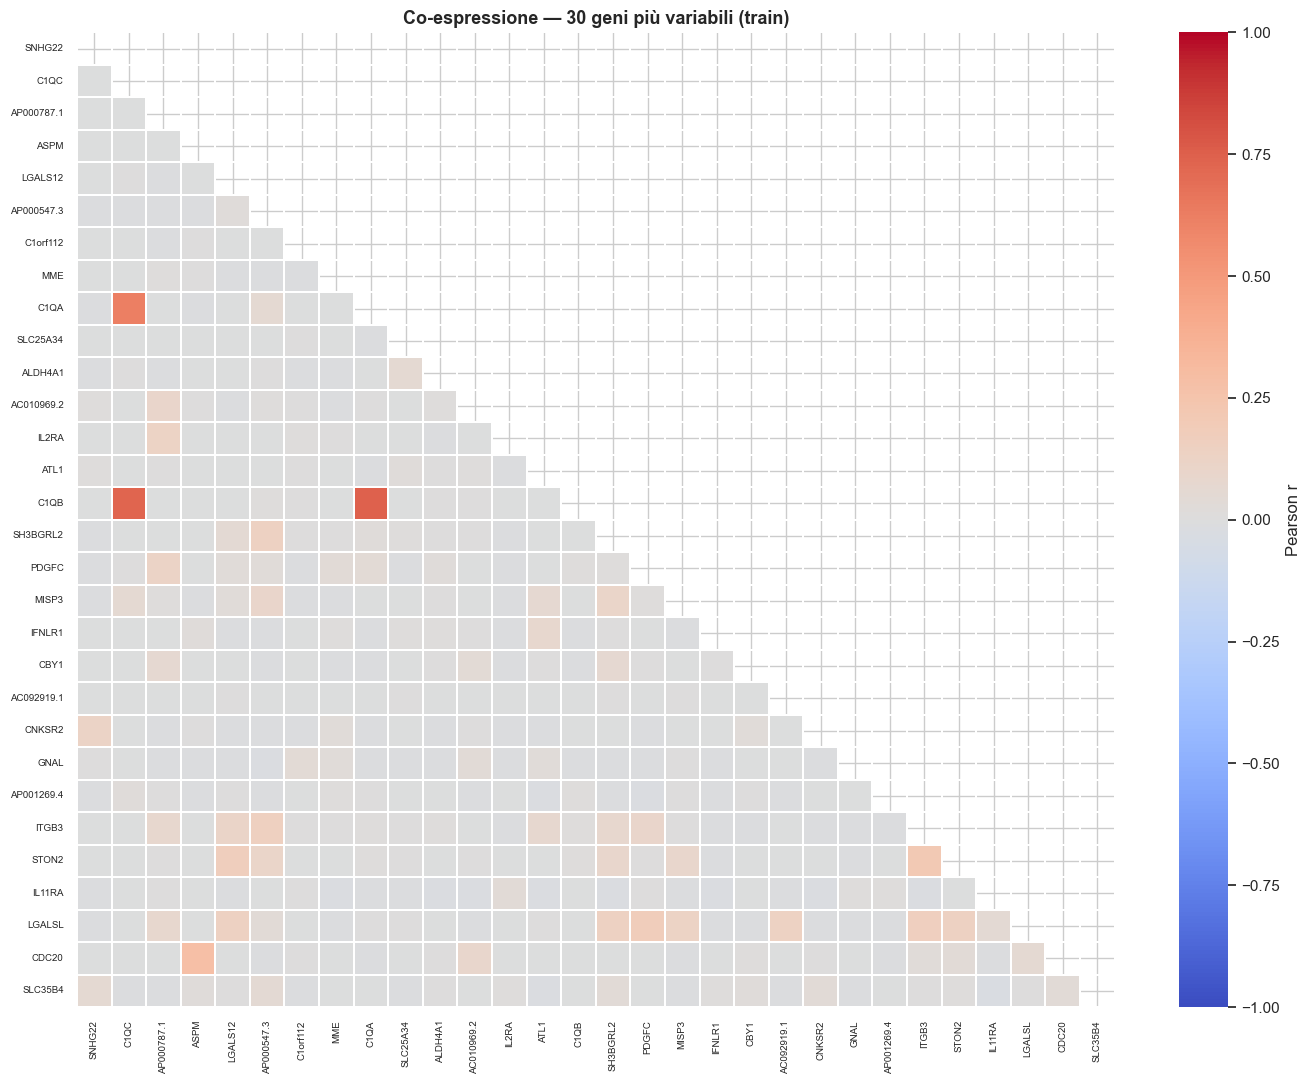

Figura salvata.

Top 8 coppie di geni più correlate (co-espressione):
C1QB    C1QA      0.748
        C1QC      0.731
C1QA    C1QC      0.624
CDC20   ASPM      0.286
STON2   ITGB3     0.218
LGALSL  PDGFC     0.175
STON2   LGALS12   0.168
LGALSL  ITGB3     0.159


In [16]:
top30_var = gene_var.head(30).index
corr      = X_train[top30_var].corr()
mask_tri  = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask_tri, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, cbar_kws={"label": "Pearson r"}
)
ax.set_title("Co-espressione — 30 geni più variabili (train)", fontsize=13, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_correlation_top30.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

# Coppie più correlate
corr_pairs = corr.where(~mask_tri).stack().sort_values(ascending=False)
print("\nTop 8 coppie di geni più correlate (co-espressione):")
print(corr_pairs.head(8).round(3).to_string())

**Lettura.** I blocchi di colore uniforme indicano gruppi di geni co-espressi (stesso
pathway o stesso tipo cellulare). I modelli ad albero li gestiscono in modo naturale.

---
## 8 · PCA — varianza spiegata e scatter 2D

La **PCA** proietta i dati sulle direzioni di massima varianza.

- **8a** — Curva della varianza spiegata: quanti componenti servono per catturare
  l'80% della varianza? Indica la "dimensionalità effettiva" del dataset.
- **8b** — Scatter 2D (PC1 vs PC2): se i tipi cellulari formano cluster separati,
  la classificazione sarà più facile.

Componenti totali: 1976
Componenti per l'80% della varianza: 888
Componenti per il 90% della varianza: 1208
  Primi  10 componenti → 14.0%
  Primi  50 componenti → 20.9%
  Primi 100 componenti → 27.0%
  Primi 200 componenti → 37.4%


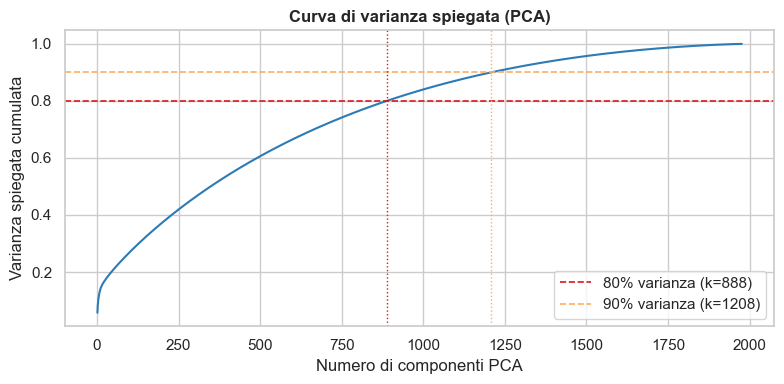

Figura salvata.


In [17]:
# ── 8a · Varianza spiegata ───────────────────────────────────────────────────
pca_full = PCA(random_state=42).fit(X_train.values)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = len(cum_var)

k80 = int(np.searchsorted(cum_var, 0.80)) + 1
k90 = int(np.searchsorted(cum_var, 0.90)) + 1
print(f"Componenti totali: {n_comp}")
print(f"Componenti per l'80% della varianza: {k80}")
print(f"Componenti per il 90% della varianza: {k90}")
for k in [10, 50, 100, 200]:
    print(f"  Primi {k:>3d} componenti → {cum_var[k-1]:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp + 1), cum_var, color="#2c7bb6", lw=1.5)
ax.axhline(0.80, ls="--", color="#d7191c", lw=1.2, label=f"80% varianza (k={k80})")
ax.axhline(0.90, ls="--", color="#fdae61", lw=1.2, label=f"90% varianza (k={k90})")
ax.axvline(k80,  ls=":",  color="#d7191c", lw=1.0)
ax.axvline(k90,  ls=":",  color="#fdae61", lw=1.0)
ax.set_xlabel("Numero di componenti PCA")
ax.set_ylabel("Varianza spiegata cumulata")
ax.set_title("Curva di varianza spiegata (PCA)", fontweight="bold")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

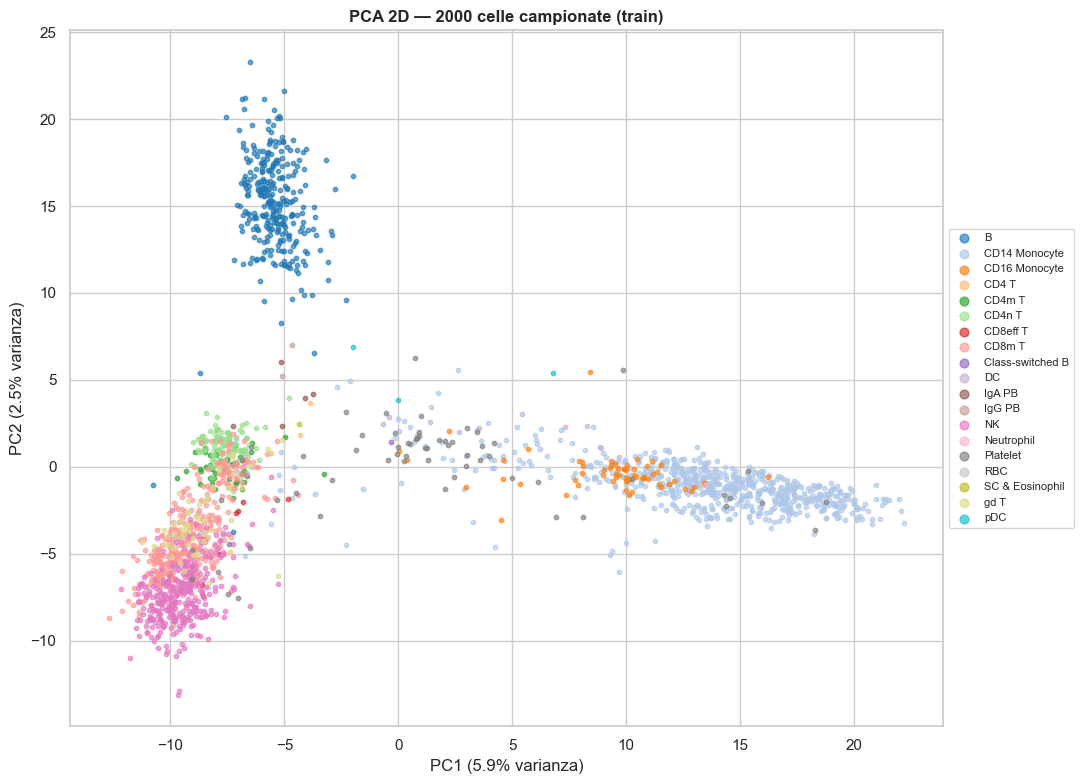

Figura salvata.


In [18]:
# ── 8b · Scatter PCA 2D ──────────────────────────────────────────────────────
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)
pca2  = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_train.iloc[idx].values)
lab    = y_train.iloc[idx].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("tab20", n_colors=lab.nunique())
for color, ct in zip(palette, sorted(lab.unique())):
    m = (lab == ct).values
    ax.scatter(coords[m, 0], coords[m, 1], s=10, alpha=0.65, label=ct, color=color)

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} varianza)")
ax.set_title(f"PCA 2D — {len(idx)} celle campionate (train)", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, markerscale=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

**Lettura.**
- La **curva di varianza** sale lentamente: servono ~888 componenti per l'80% e ~1208 per il 90%.
  I dati, già normalizzati per gene (varianza ~1 ciascuno), sono quindi **poco comprimibili**
  linearmente — non esiste una manciata di direzioni dominanti.
- I primi 50 componenti catturano solo ~21% della varianza: usare `PCA(50)` come preprocessing
  dell'SVM lineare è una scelta di **velocità/regolarizzazione** (riduce le dimensioni), non una
  compressione quasi senza perdita.
- Lo **scatter 2D** (PC1+PC2 ≈ pochi %) separa solo alcuni tipi cellulari (es. Platelet, Monociti);
  gli altri si sovrappongono e richiedono molte più dimensioni o modelli multivariati.

---
## 9 · Conclusioni — collegamento con i modelli

| Osservazione EDA | Scelta metodologica nei modelli |
|---|---|
| Dataset fortemente sbilanciato (rapporto fino a 755:1) | `class_weight='balanced'` in tutti i modelli |
| Sbilanciamento rende l'accuracy ingannevole | Metriche principali: **Macro F1** e **balanced accuracy** |
| Potere discriminante indipendente dalla varianza grezza | I modelli ad albero usano la specificità per classe, non la varianza grezza |
| IL7R, CD3E → T-cell \| PF4 → Platelet (criterio 1σ) | Coerente con feature importance e SHAP nel notebook ML |
| Forte co-espressione tra geni (blocchi in heatmap) | Modelli ad albero (RF, LightGBM) gestiscono bene feature correlate |
| Dati poco comprimibili con PCA (80% var ≈ 888 PC) | `PCA(50)` per l'SVM è scelta di velocità/regolarizzazione, non compressione |
| Cluster visibili in PCA 2D con sovrapposizioni | Servono modelli multivariati; classificazione lineare pura non basta |

**Prossimo passo:** `Machine_learning_models.ipynb` — addestramento e confronto dei classificatori.